In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
def separate_sides(pi_data):
    left_df = pi_data[pi_data['foot'] == 'left']
    right_df = pi_data[pi_data['foot'] == 'right']

    left_data = pi_reshape(left_df)
    right_data = pi_reshape(right_df)
    return left_data, right_data

def pi_reshape(side_df):
    """
    reshapes continuous df to 3D array [31 x 11 x number of frames]
    :param side_df: continuous df
    :return: 3d array [31 x 11 x number of frames]
    """
    frames = side_df['frame'].unique()
    side_array = np.empty([31,11,frames[-1]])
    for i in frames:
        side_array[:, :, i - 1] = side_df.loc[side_df['frame'] == i, '0':'10'].values
    return side_array

def pi_remove_offset(array3_raw, fs):
    """
    removes pressure offset during swing
    :param array3_raw: 3D array with pressure data from 1 side (31 x 11 x frames)
    :param fs: sampling rate - int
    :return: offset removed pressure data
    """
    # calculate force
    force = pi_force(array3_raw)
    # calculate IC
    ic = pi_ic(force, fs)

    array3 = np.empty(array3_raw.shape)
    # for every ic: find largest offset frame in previous 0.25 s
    # substract this offset from all frames between current and previous IC
    for i in range(len(ic)):
        if i == 0:
            if ic[i]==0:
                continue
            else:
                array3[:, :, :ic[i]] = offset_stage1(array3_raw[:, :, :ic[i]], fs)
        else: # maybe remove "-1"
            array3[:, :, ic[i-1]:ic[i]] = offset_stage1(array3_raw[:, :, ic[i-1]:ic[i]], fs)

    return array3, ic, force

def pi_force(array3):
    return np.sum(np.sum(array3, axis=0), axis=0)

def pi_ic(force_side, sampling_rate):

    # calculate rate of force development (1st derivative of force)
    rfd = np.diff(force_side, n=1)*sampling_rate   # unit N/s

    # find where rfd > 1500 N/s based on Seiberl et al. (2018)
    rfd_1500 = np.where(rfd > 1500)[0]
    rfd_1500 = list(rfd_1500[rfd_1500<len(force_side)-sampling_rate//20])
    IC_side = []

    # loop over all indices of rfd_1500
    for IC in rfd_1500:
        # check if force increases monotonically by at least 1000 N in next 0.05s
        # TODO: needs to be checked
        if ((force_side[IC+sampling_rate//20]) > (force_side[IC]+1000)) & (min(force_side[IC:IC+sampling_rate//20]) == force_side[IC:IC+sampling_rate//20][0]):
            # first ic
            if len(IC_side) == 0:
                IC_side.append(IC)
            # all further ic have to be at least 0.25s apart
            elif IC > IC_side[-1]+sampling_rate//4:
                IC_side.append(IC)

    return np.array(IC_side, dtype=int)

def find_max_offset(array3, fs):
    if array3.shape[2] < fs//4:
        offset = np.mean(array3, axis=2)
    else:
        offset = np.mean(array3[:,:,-fs//4:], axis = 2)
    return offset
#def find_max_offset(array3, fs):
#    if array3.shape[2] < fs//4:
#        offset = array3[:, :,0]
#        for frame in range(array3.shape[2]):
#            if np.sum(offset)<np.sum(array3[:,:,frame]):
#                offset = array3[:,:,frame]
#    else:
#        offset = array3[:, :, -fs//4]
#        for frame in range(-fs//4,-1):
#            if np.sum(offset)<np.sum(array3[:,:,frame]):
#                offset = array3[:,:,frame]
#    return offset

def offset_stage1(array3, fs):
    offset = find_max_offset(array3, fs)
    for frame in range(array3.shape[2]):
        array3[:,:,frame]-=offset
    array3[array3<0]=0
    return array3

In [3]:
df = pd.read_csv('D:\\Salzburg\\Study1\\P01\\P01_PI_df\\BOS_down_8.csv', index_col = 0)
df.set_index(np.linspace(0, len(df)-1, len(df)))
df

,0,1,2,3,4,5,6,7,8,9,10,foot,frame,row_count
0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,left,1,1
1,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,left,1,2
2,0.0,0.0,0.00,0.00,1.35,2.20,1.05,1.50,2.01,1.49,0.0,left,1,3
3,0.0,0.0,0.00,2.35,2.05,1.47,1.54,2.53,3.16,3.39,0.0,left,1,4
4,0.0,0.0,1.14,1.40,0.00,0.00,0.00,1.65,4.18,5.75,0.0,left,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581976,0.0,0.0,0.00,0.00,0.00,1.93,1.59,1.51,0.00,0.00,0.0,right,6000,27
581977,0.0,0.0,0.00,0.00,0.00,1.51,2.24,2.13,1.36,0.00,0.0,right,6000,28
581978,0.0,0.0,0.00,0.00,0.00,1.44,5.16,3.32,1.62,0.00,0.0,right,6000,29
581979,0.0,0.0,0.00,0.00,0.00,1.52,3.48,2.91,1.64,0.00,0.0,right,6000,30


In [4]:
left_raw, right_raw = separate_sides(df)
# remove offset
left, ic_left, fl_raw = pi_remove_offset(left_raw, 100)
right, ic_right, fr_raw = pi_remove_offset(right_raw, 100)
force_left = pi_force(left)
force_right = pi_force(right)

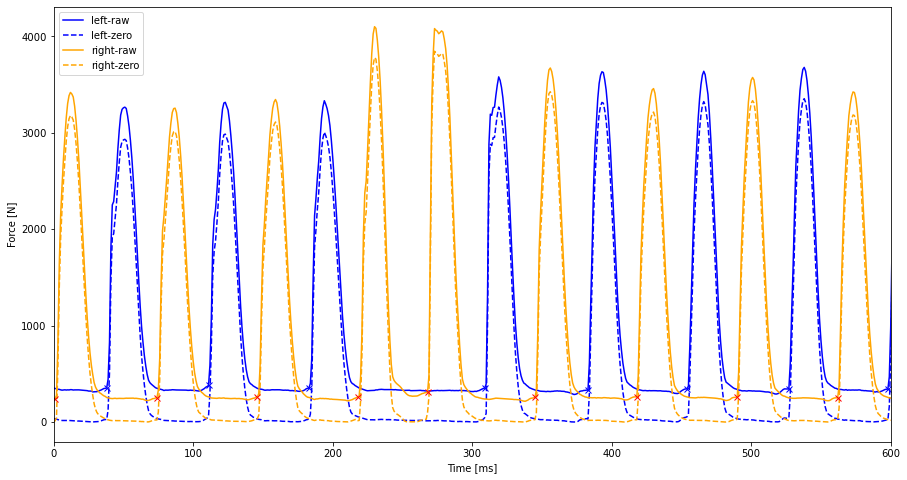

In [17]:
plt.plot(fl_raw, label='left-raw', color = 'blue')
plt.plot(force_left, label='left-zero', color = 'blue', linestyle='--')
plt.plot(fr_raw, label='right-raw', color = 'orange')
plt.plot(force_right, label='right-zero', color = 'orange', linestyle= '--')

plt.plot(ic_right, fr_raw[ic_right], 'rx')
plt.plot(ic_left, fl_raw[ic_left], 'bx')
plt.xlim(0,600)
#plt.ylim(0,100)
plt.xlabel('Time [ms]')
plt.ylabel('Force [N]')
plt.legend()
fig = plt.gcf()
fig.set_size_inches(15, 8)

In [6]:
def find_max_offset(array3, fs):
    if array3.shape[2] < fs//4:
        offset = array3[:, :, 0]
        for frame in range(array3.shape[2]):
            if np.sum(offset)<np.sum(array3[:,:,frame]):
                offset = array3[:,:,frame]
    else:
        offset = array3[:, :, -fs//4]
        for frame in range(-fs//4,-1):
            if np.sum(offset)<np.sum(array3[:,:,frame]):
                offset = array3[:,:,frame]
    return offset

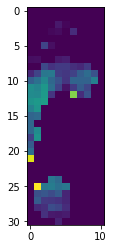

In [7]:
off1 = find_max_offset(left_raw[:,:,:ic_left[0]+1],100)
plt.imshow(off1)

NameError: name 'f_right_raw' is not defined

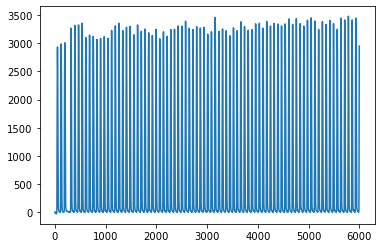

In [8]:
for frame in range(left_raw[:,:,:ic_left[0]+1].shape[2]):
    left_raw[:,:,frame] = left_raw[:,:,frame] - off1
f_left_raw = np.sum(np.sum(left_raw, axis=0), axis=0)
plt.plot(f_left_raw, label='left')
plt.plot(f_right_raw, label='right')
plt.plot(ic_right, f_right_raw[ic_right], 'rx')
plt.plot(ic_left, f_left_raw[ic_left], 'bx')
plt.xlim(0,1000)
plt.legend()
fig = plt.gcf()
fig.set_size_inches(15, 8)

In [ ]:
pd.read_csv(r'D:\Salzburg\Study1\P01\P01_PI_df\output\temp_params_UB_up_9.csv', header = [0,1])